In [4]:
import pandas as pd
df = pd.read_parquet("Data/yellow_tripdata_2023-01.parquet")
df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00
5,2,2023-01-01 00:50:34,2023-01-01 01:02:52,1.0,1.84,1.0,N,161,137,1,12.8,1.00,0.5,10.00,0.0,1.0,27.80,2.5,0.00
6,2,2023-01-01 00:09:22,2023-01-01 00:19:49,1.0,1.66,1.0,N,239,143,1,12.1,1.00,0.5,3.42,0.0,1.0,20.52,2.5,0.00
7,2,2023-01-01 00:27:12,2023-01-01 00:49:56,1.0,11.70,1.0,N,142,200,1,45.7,1.00,0.5,10.74,3.0,1.0,64.44,2.5,0.00
8,2,2023-01-01 00:21:44,2023-01-01 00:36:40,1.0,2.95,1.0,N,164,236,1,17.7,1.00,0.5,5.68,0.0,1.0,28.38,2.5,0.00
9,2,2023-01-01 00:39:42,2023-01-01 00:50:36,1.0,3.01,1.0,N,141,107,2,14.9,1.00,0.5,0.00,0.0,1.0,19.90,2.5,0.00


In [5]:
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object

In [6]:
df['VendorID'] = df['VendorID'].astype('int32')
df['passenger_count'] = df['passenger_count'].fillna(0).astype('int32')
df['RatecodeID'] = df['RatecodeID'].fillna(99).astype('int32')
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype('string')
df['PULocationID'] = df['PULocationID'].astype('int32')
df['DOLocationID'] = df['DOLocationID'].astype('int32')
df['payment_type'] = df['payment_type'].astype('int32')
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int32
trip_distance                   float64
RatecodeID                        int32
store_and_fwd_flag       string[python]
PULocationID                      int32
DOLocationID                      int32
payment_type                      int32
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object

In [7]:
filtered_df = df[(df['VendorID'] == 1) &
                 (df['payment_type'].isin([1, 2])) &
                 (df['trip_distance'] > 5)]
filtered_df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
11,1,2023-01-01 00:43:37,2023-01-01 01:17:18,4,7.3,1,N,79,264,1,33.8,3.50,0.5,7.75,0.00,1.0,46.55,2.5,0.00
21,1,2023-01-01 00:13:30,2023-01-01 00:44:00,1,17.8,2,N,132,116,1,70.0,1.25,0.5,15.85,6.55,1.0,95.15,0.0,1.25
31,1,2023-01-01 00:51:55,2023-01-01 01:19:20,1,9.5,1,N,263,36,1,38.7,3.50,0.5,15.05,6.55,1.0,65.30,2.5,0.00
64,1,2023-01-01 00:18:29,2023-01-01 00:55:20,1,11.3,1,N,163,225,1,48.5,3.50,0.5,10.70,0.00,1.0,64.20,2.5,0.00
110,1,2023-01-01 00:04:45,2023-01-01 00:45:38,1,9.7,1,N,161,228,1,50.6,3.50,0.5,16.65,0.00,1.0,72.25,2.5,0.00
117,1,2023-01-01 00:36:10,2023-01-01 00:57:32,1,9.0,1,N,137,212,1,35.9,3.50,0.5,0.00,0.00,1.0,40.90,2.5,0.00
127,1,2023-01-01 00:11:35,2023-01-01 00:34:22,1,6.0,1,N,107,166,2,26.8,3.50,0.5,0.00,0.00,1.0,31.80,2.5,0.00
168,1,2023-01-01 00:21:15,2023-01-01 00:52:25,1,19.2,1,N,132,25,1,72.3,2.25,0.5,15.20,0.00,1.0,91.25,0.0,1.25
176,1,2023-01-01 00:48:00,2023-01-01 01:28:58,1,5.8,1,N,231,239,1,38.7,3.50,0.5,6.56,0.00,1.0,50.26,2.5,0.00
193,1,2023-01-01 00:51:02,2023-01-01 01:17:09,1,6.7,1,N,68,33,1,33.1,3.50,0.5,6.00,0.00,1.0,44.10,2.5,0.00


In [8]:
def calc_duration(pickup, dropoff):
    return (dropoff - pickup).total_seconds() / 60

df['trip_duration'] = df.apply(lambda row: calc_duration(row['tpep_pickup_datetime'], row['tpep_dropoff_datetime']), axis=1)
df[['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_duration']].head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,8.433333
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,6.316667
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,12.750000
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,9.616667
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,10.833333
5,2,2023-01-01 00:50:34,2023-01-01 01:02:52,12.300000
6,2,2023-01-01 00:09:22,2023-01-01 00:19:49,10.450000
7,2,2023-01-01 00:27:12,2023-01-01 00:49:56,22.733333
8,2,2023-01-01 00:21:44,2023-01-01 00:36:40,14.933333
9,2,2023-01-01 00:39:42,2023-01-01 00:50:36,10.900000


In [9]:
grouped_df = df.groupby('payment_type').agg(
    total_amount_mean=('total_amount', 'mean'),
    total_amount_std=('total_amount', 'std'),
    tip_amount_max=('tip_amount', 'max'),
    tip_amount_min=('tip_amount', 'min')
).reset_index()

grouped_df.to_csv('ptype-amount.csv', index=False)
grouped_df

,payment_type,total_amount_mean,total_amount_std,tip_amount_max,tip_amount_min
0,0,29.133590,17.057965,40.00,-5.78
1,1,28.298442,21.961932,380.80,-64.66
2,2,23.034783,20.681099,55.79,0.00
3,3,10.506835,32.222646,270.30,-20.00
4,4,2.553484,34.034054,99.88,-96.22


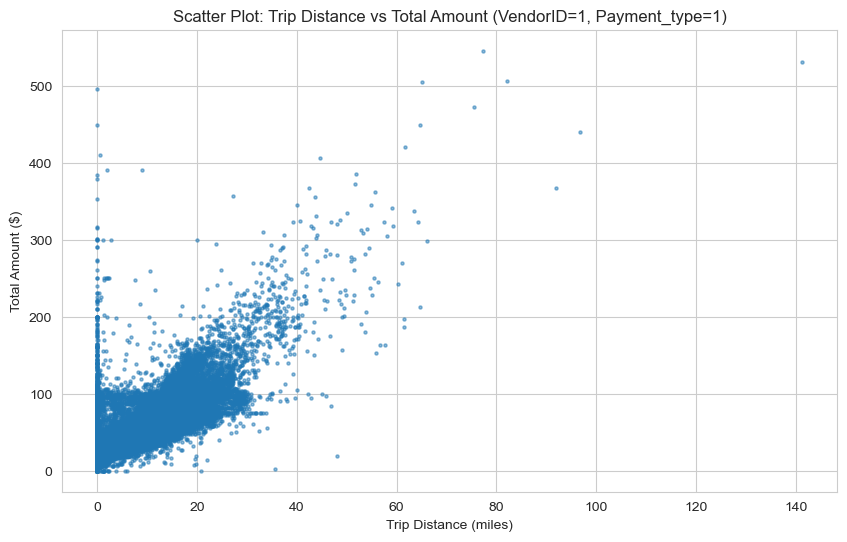

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
filtered_data = df[(df['VendorID'] == 1) & (df['payment_type'] == 1)]

plt.figure(figsize=(10, 6))
plt.scatter(filtered_data['trip_distance'], filtered_data['total_amount'], alpha=0.5, s=5)
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Total Amount ($)')
plt.title('Scatter Plot: Trip Distance vs Total Amount (VendorID=1, Payment_type=1)')
plt.show()